In [1]:
from qiskit import QuantumCircuit
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import time
from qiskit.quantum_info import Statevector, state_fidelity

start = time.time()

%matplotlib inline

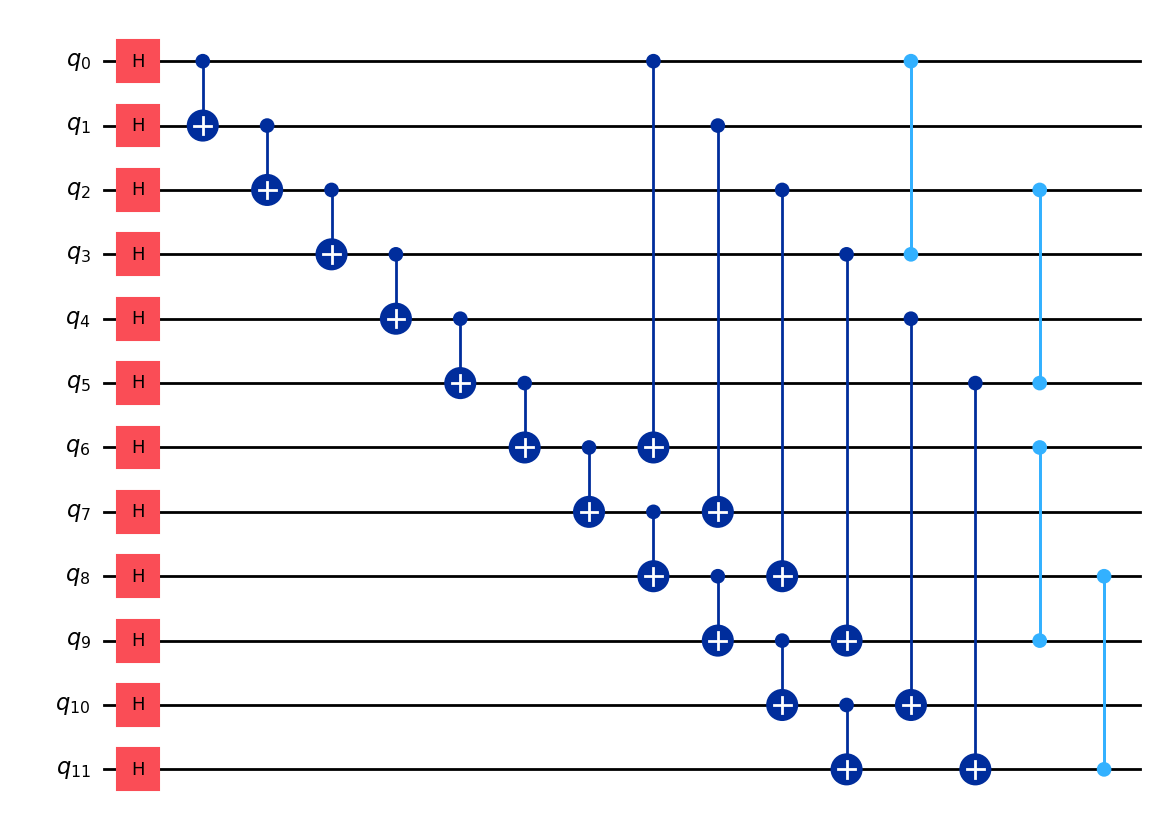

In [3]:


qc = QuantumCircuit(12)

for i in range(12):
    qc.h(i)

for i in range(11):
    qc.cx(i, i+1)

qc.cx(0,6)
qc.cx(1,7)
qc.cx(2,8)
qc.cx(3,9)
qc.cx(4,10)
qc.cx(5,11)

qc.cz(0,3)
qc.cz(2,5)
qc.cz(6,9)
qc.cz(8,11)

qc.draw("mpl");

In [4]:


G = nx.Graph()

for q in range(qc.num_qubits):
    G.add_node(q)

for instruction in qc.data:

    if len(instruction.qubits) == 2:

        q0 = qc.qubits.index(instruction.qubits[0])
        q1 = qc.qubits.index(instruction.qubits[1])

        gate_name = instruction.operation.name

        G.add_edge(q0, q1, gate=gate_name)

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Edges: [(0, 1), (0, 6), (0, 3), (1, 2), (1, 7), (2, 3), (2, 8), (2, 5), (3, 4), (3, 9), (4, 5), (4, 10), (5, 6), (5, 11), (6, 7), (6, 9), (7, 8), (8, 9), (8, 11), (9, 10), (10, 11)]


In [5]:
# brute force algorithm
all_qubits = set(range(qc.num_qubits))

best_partition = None
best_cuts = None
minimum_cut_count = float("inf")

for size in range(3, qc.num_qubits // 2 + 1):

    for subset in combinations(all_qubits, size):

        partA = set(subset)
        partB = all_qubits - partA

        cut_edges = []

        for u, v, data in G.edges(data=True):

            if (u in partA and v in partB) or \
               (u in partB and v in partA):

                cut_edges.append((u, v, data["gate"]))

        if len(cut_edges) < minimum_cut_count:

            minimum_cut_count = len(cut_edges)
            best_partition = (partA, partB)
            best_cuts = cut_edges



In [6]:
end = time.time()

runtime = end - start

print("Runtime =", runtime, "seconds")

Runtime = 33.55741047859192 seconds


In [7]:
partA, partB = best_partition

print("Group A =", sorted(partA))
print("Group B =", sorted(partB))

print("\nCut Gates:")

for u, v, gate in best_cuts:
    print(f"{gate.upper()} between q{u} and q{v}")

print("\nTotal Cuts =", minimum_cut_count)

Group A = [0, 1, 7]
Group B = [2, 3, 4, 5, 6, 8, 9, 10, 11]

Cut Gates:
CX between q0 and q6
CZ between q0 and q3
CX between q1 and q2
CX between q6 and q7
CX between q7 and q8

Total Cuts = 5


In [8]:
def extract_subcircuit(circuit, qubit_group, name):

    ordered = sorted(qubit_group) # sort the qubits in each group to maintain a consistent order

    mapping = {
        old: new
        for new, old in enumerate(ordered) # create a mapping from original qubit indices to new indices in the subcircuit(i.e change quibit 7 in group a to qubit 0 in the subcircuit)
    }

    sub = QuantumCircuit(len(qubit_group), name=name) # create a new quantum circuit with the number of qubits equal to the size of the group and assign it the given name

    for instruction in circuit.data: # iterate through each gate in the original circuit

        indices = [
            circuit.qubits.index(q)
            for q in instruction.qubits
        ] # get the original qubit indices for the current gate
          # find which quibits the gate acts on. i.e for cx(0,6) it will return indices = [0,6]

        if all(i in qubit_group for i in indices):

            sub.append(
                instruction.operation,
                [mapping[i] for i in indices]
            ) # if all qubits involved in the gate are in the current group, add the gate to the subcircuit with remapped qubit indices i.e for cx(0,6) if both 0 and 6 are in group A, it will add cx(0,6) to the subcircuit but with remapped indices based on the mapping dictionary. If 0 is mapped to 0 and 6 is mapped to 1 in the subcircuit, it will add cx(0,1) to the subcircuit.

    return sub

In [9]:
subA = extract_subcircuit(qc, partA, "SubA")
subB = extract_subcircuit(qc, partB, "SubB")

In [10]:
original_state = Statevector.from_instruction(qc)

reconstructed_qc = QuantumCircuit(qc.num_qubits)

for instruction in qc.data:

    indices = [
        qc.qubits.index(q)
        for q in instruction.qubits
    ]

    keep_gate = False

    if len(indices) == 1:
        keep_gate = True

    elif all(i in partA for i in indices):
        keep_gate = True

    elif all(i in partB for i in indices):
        keep_gate = True

    if keep_gate:

        reconstructed_qc.append(
            instruction.operation,
            indices
        )

reconstructed_state = Statevector.from_instruction(
    reconstructed_qc
)

fidelity = state_fidelity(
    original_state,
    reconstructed_state
)

print("Fidelity =", fidelity)

Fidelity = 0.2499999999999999


Subcircuit A
Subcircuit B


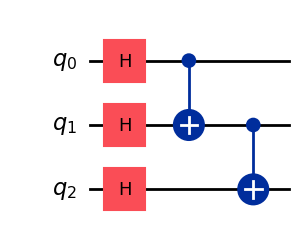

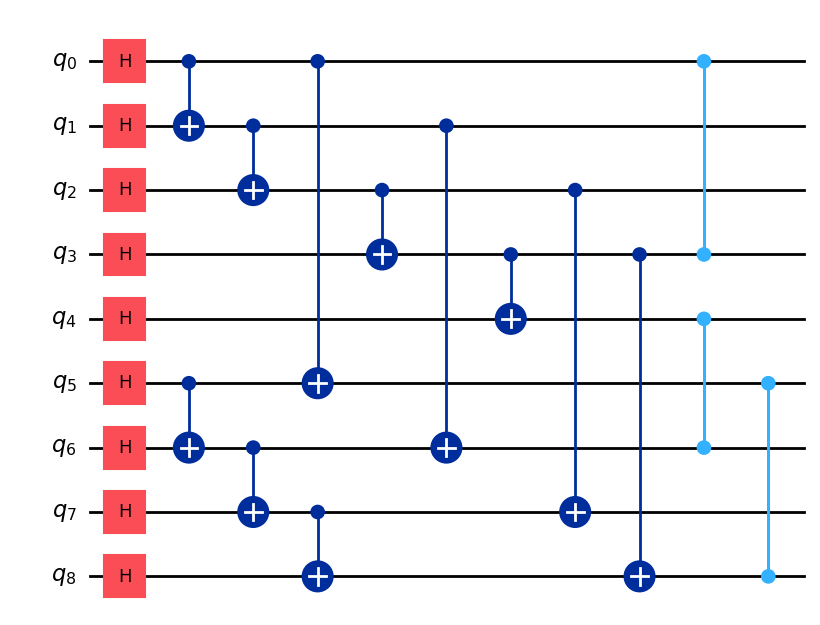

In [9]:
print("Subcircuit A")
subA.draw("mpl");

print("Subcircuit B")
subB.draw("mpl");

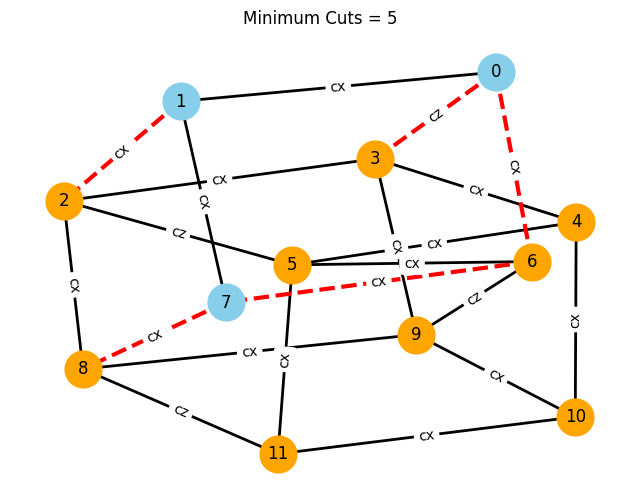

In [10]:


plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

cut_edges = [(u,v) for u,v,gate in best_cuts] # remove the gate information from best_cuts to get just the edges that are cut

normal_edges = []

for e in G.edges():

    if e not in cut_edges and (e[1],e[0]) not in cut_edges:
        normal_edges.append(e)

nx.draw_networkx_nodes( # draw nodes for part A in skyblue
    G,
    pos,
    nodelist=list(partA),
    node_color="skyblue",
    node_size=700
)

nx.draw_networkx_nodes( # draw nodes for part B in orange
    G,
    pos,
    nodelist=list(partB),
    node_color="orange",
    node_size=700
)

nx.draw_networkx_labels(G,pos) # draw node labels (qubit indices) at the positions. without this we'd only see circles.

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=normal_edges,
    width=2
)

nx.draw_networkx_edges( # draw cut edges in red and dashed to highlight them
    G,
    pos,
    edgelist=cut_edges,
    edge_color="red",
    style="dashed",
    width=3
)

edge_labels = nx.get_edge_attributes(G,"gate") # get the gate names for all edges to use as labels. this will create a dictionary where the keys are edge tuples (u,v) and the values are the gate names. for example, if there's a cx gate between qubits 0 and 6, it will have an entry like {(0,6): "cx", (6,0): "cx"} since it's an undirected graph.

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title(f"Minimum Cuts = {minimum_cut_count}")

plt.axis("off")
plt.show()

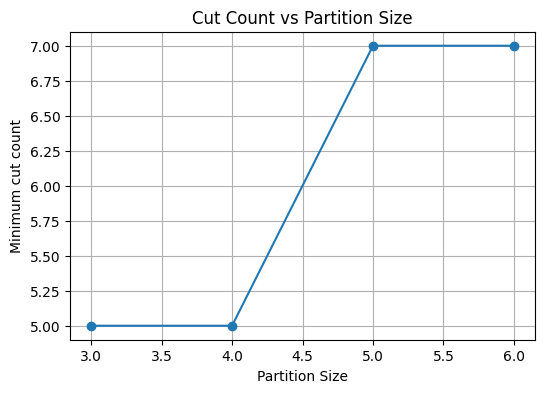

In [12]:
cut_counts = []

for size in range(3, qc.num_qubits // 2 + 1):

    best_for_size = float('inf')

    for subset in combinations(all_qubits, size):

        partA = set(subset)
        partB = all_qubits - partA

        count = 0

        for u, v in G.edges():

            if (u in partA and v in partB) or \
               (u in partB and v in partA):

                count += 1

        best_for_size = min(best_for_size, count)

    cut_counts.append(best_for_size)

plt.figure(figsize=(6,4))
plt.plot(range(3, qc.num_qubits // 2 + 1),
         cut_counts,
         marker='o')

plt.xlabel("Partition Size")
plt.ylabel("Minimum cut count")
plt.title("Cut Count vs Partition Size")
plt.grid(True)

plt.show()